# 🎬 Multimodal Movie Genre Classification
## IMDB Four-Genre Posters · MobileNetV2 + BiLSTM · Keras / TensorFlow

---

| Property | Detail |
|----------|--------|
| **Dataset** | Local `IMDB four_genre_posters/` + `IMDB_four_genre_larger_plot_description.csv` |
| **Classes** | Action · Comedy · Horror · Romance |
| **Task** | 4-class movie genre classification |
| **Image branch** | MobileNetV2 pretrained on ImageNet (frozen) → Dense(256) |
| **Text branch** | Embedding → Bidirectional LSTM(128) × 2 → Dense(256) |
| **Fusion** | Late fusion — Concatenate → Dense(256) → Dense(4, softmax) |
| **Framework** | **Keras / TensorFlow 2.x** |

[![Multimodal.png](https://i.postimg.cc/c4spWbw1/Multimodal.png)](https://postimg.cc/8s0KBwZx)

## 1. Install & Import

In [1]:
!pip install -q tensorflow matplotlib scikit-learn pandas numpy pillow visualkeras
print('✅ All packages installed')

✅ All packages installed



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, re, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from collections import Counter
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint)
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score)
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print(f'TensorFlow : {tf.__version__}')
print(f'Keras      : {keras.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs       : {gpus if gpus else "None (CPU mode)"}')

plt.rcParams.update({
    'figure.facecolor':'#0d0d1a', 'axes.facecolor':'#111128',
    'axes.edgecolor':'#3a3a5c',   'axes.labelcolor':'#d0d0e8',
    'xtick.color':'#9090b0',      'ytick.color':'#9090b0',
    'text.color':'#d0d0e8',       'grid.color':'#2a2a44',
    'grid.linestyle':'--',        'font.size':11,
    'axes.titlesize':12,          'legend.facecolor':'#1a1a30',
    'legend.edgecolor':'#3a3a5c',
})
print('✅ Imports complete')

TensorFlow : 2.20.0
Keras      : 3.13.2
GPUs       : None (CPU mode)
✅ Imports complete


## 2. Configuration — Set Your Paths Here

```
IMDB four_genre_posters/
├── Action/    ← {movie_id}.jpg
├── Comedy/
├── Horror/
└── Romance/
```

In [3]:
# ── ⚠️  SET THESE PATHS TO YOUR LOCAL DIRECTORIES ─────────────────────────
POSTER_DIR  = 'IMDB'          # folder with Action/Comedy/Horror/Romance sub-dirs
CSV_PATH    = 'IMDB.csv'
# ──────────────────────────────────────────────────────────────────────────

CLASSES     = ['action', 'comedy', 'horror', 'romance']
N_CLASSES   = len(CLASSES)
IMG_SIZE    = 224          # MobileNetV2 input size
MAX_LEN     = 200          # max tokens per plot description
VOCAB_SIZE  = 20000        # top-N words to keep
EMBED_DIM   = 128          # word embedding dimension
BATCH_SIZE  = 32
EPOCHS      = 10

# ImageNet normalization constants
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

print('Configuration:')
print(f'  POSTER_DIR : {POSTER_DIR}')
print(f'  CSV_PATH   : {CSV_PATH}')
print(f'  Classes    : {CLASSES}')
print(f'  IMG_SIZE   : {IMG_SIZE}x{IMG_SIZE}')
print(f'  MAX_LEN    : {MAX_LEN} tokens')
print(f'  VOCAB_SIZE : {VOCAB_SIZE}')
print(f'  BATCH_SIZE : {BATCH_SIZE}')
print(f'  EPOCHS     : {EPOCHS}')

Configuration:
  POSTER_DIR : IMDB
  CSV_PATH   : IMDB.csv
  Classes    : ['action', 'comedy', 'horror', 'romance']
  IMG_SIZE   : 224x224
  MAX_LEN    : 200 tokens
  VOCAB_SIZE : 20000
  BATCH_SIZE : 32
  EPOCHS     : 10


## 3. Load & Merge Dataset

In [4]:
# ── Load CSV ────────────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)
df['genre'] = df['genre'].str.strip().str.lower()
print(f'CSV loaded: {df.shape[0]} rows')
print(f'Columns   : {df.columns.tolist()}')
print(f'Genre dist:\n{df["genre"].value_counts()}')

CSV loaded: 1000 rows
Columns   : ['movie_id', 'description', 'genre']
Genre dist:
genre
romance    250
horror     250
comedy     250
action     250
Name: count, dtype: int64


In [5]:
# ── Scan poster folder & build image path map ────────────────────────────────
# Expected: POSTER_DIR/{Genre}/{movie_id}.jpg  (or .png)
img_map = {}  # movie_id -> absolute image path
supported_exts = {'.jpg', '.jpeg', '.png', '.webp'}

for genre_folder in os.listdir(POSTER_DIR):
    genre_path = os.path.join(POSTER_DIR, genre_folder)
    if not os.path.isdir(genre_path):
        continue
    for fname in os.listdir(genre_path):
        name, ext = os.path.splitext(fname)
        if ext.lower() in supported_exts:
            img_map[name] = os.path.join(genre_path, fname)

print(f'Total posters found  : {len(img_map):,}')

# Match CSV rows to available posters
df['img_path'] = df['movie_id'].map(img_map)
df_matched     = df[df['img_path'].notna()].reset_index(drop=True)
df_missing     = df[df['img_path'].isna()]

print(f'CSV rows             : {len(df):,}')
print(f'Matched (CSV+poster) : {len(df_matched):,}')
print(f'Missing poster       : {len(df_missing):,}')
print(f'\nMatched genre dist:\n{df_matched["genre"].value_counts()}')

# Use matched subset going forward
df = df_matched.copy()
print(f'\n✅ Working dataset: {len(df)} samples')

Total posters found  : 1,251
CSV rows             : 1,000
Matched (CSV+poster) : 692
Missing poster       : 308

Matched genre dist:
genre
horror     250
action     239
comedy     110
romance     93
Name: count, dtype: int64

✅ Working dataset: 692 samples


## 4. Exploratory Data Analysis (EDA)

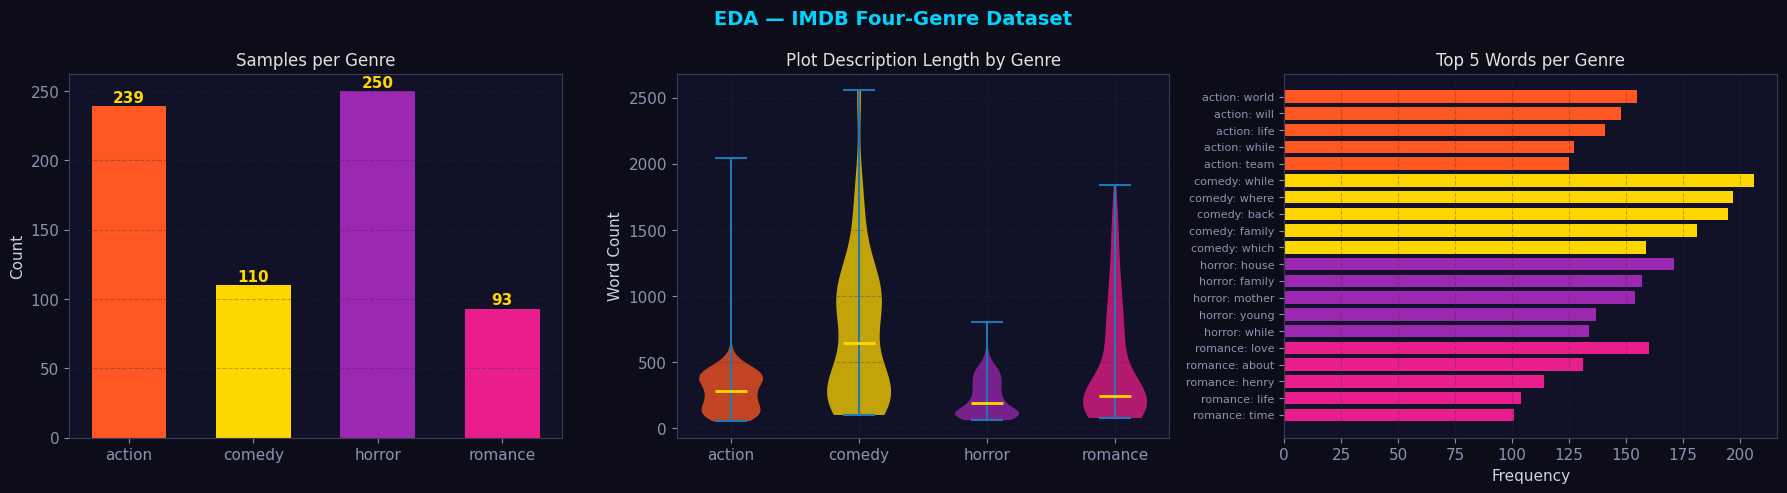

Description length — mean: 362  median: 256  max: 2557


In [6]:
df['desc_len'] = df['description'].str.split().str.len()

GENRE_COLORS = {
    'action':'#ff5722', 'comedy':'#ffd700',
    'horror':'#9c27b0', 'romance':'#e91e8c'
}
pal = [GENRE_COLORS[g] for g in CLASSES]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('EDA — IMDB Four-Genre Dataset',
             fontsize=14, fontweight='bold', color='#00d4ff')

# 1. Class distribution
counts = df['genre'].value_counts().reindex(CLASSES)
bars = axes[0].bar(counts.index, counts.values,
                   color=pal, width=0.6, edgecolor='none')
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+3, str(v),
                 ha='center', fontsize=11, color='#ffd700', fontweight='bold')
axes[0].set_title('Samples per Genre', color='#e0e0e0')
axes[0].set_ylabel('Count'); axes[0].grid(True, axis='y', alpha=0.3)

# 2. Description length by genre (violin)
data_violin = [df[df['genre']==g]['desc_len'].values for g in CLASSES]
vp = axes[1].violinplot(data_violin, positions=range(4),
                         showmedians=True, showextrema=True)
for i, pc in enumerate(vp['bodies']):
    pc.set_facecolor(pal[i]); pc.set_alpha(0.75)
vp['cmedians'].set_color('#ffd700'); vp['cmedians'].set_linewidth(2)
axes[1].set_xticks(range(4)); axes[1].set_xticklabels(CLASSES)
axes[1].set_title('Plot Description Length by Genre', color='#e0e0e0')
axes[1].set_ylabel('Word Count'); axes[1].grid(True, alpha=0.3)

# 3. Top words per genre
stopwords = {'a','an','the','is','are','in','on','at','of','and','with',
             'to','his','her','their','he','she','they','it','was','by',
             'for','as','from','that','this','but','when','who','after',
             'into','have','had','has','be','been','not','one','two',
             'him','them','its','we','our','also','then','so','but','up'}
all_top = {}
for g in CLASSES:
    text = ' '.join(df[df['genre']==g]['description']).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    wf   = Counter(w for w in text.split() if w not in stopwords and len(w)>3)
    all_top[g] = wf.most_common(5)

y_pos, y_labels, bar_vals, bar_clrs = 0, [], [], []
for g in CLASSES:
    for word, cnt in all_top[g]:
        y_labels.append(f'{g}: {word}')
        bar_vals.append(cnt)
        bar_clrs.append(GENRE_COLORS[g])
axes[2].barh(y_labels, bar_vals, color=bar_clrs, edgecolor='none', height=0.75)
axes[2].invert_yaxis()
axes[2].set_title('Top 5 Words per Genre', color='#e0e0e0')
axes[2].set_xlabel('Frequency'); axes[2].grid(True, axis='x', alpha=0.3)
axes[2].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Description length — mean: {df["desc_len"].mean():.0f}  '
      f'median: {df["desc_len"].median():.0f}  '
      f'max: {df["desc_len"].max()}')

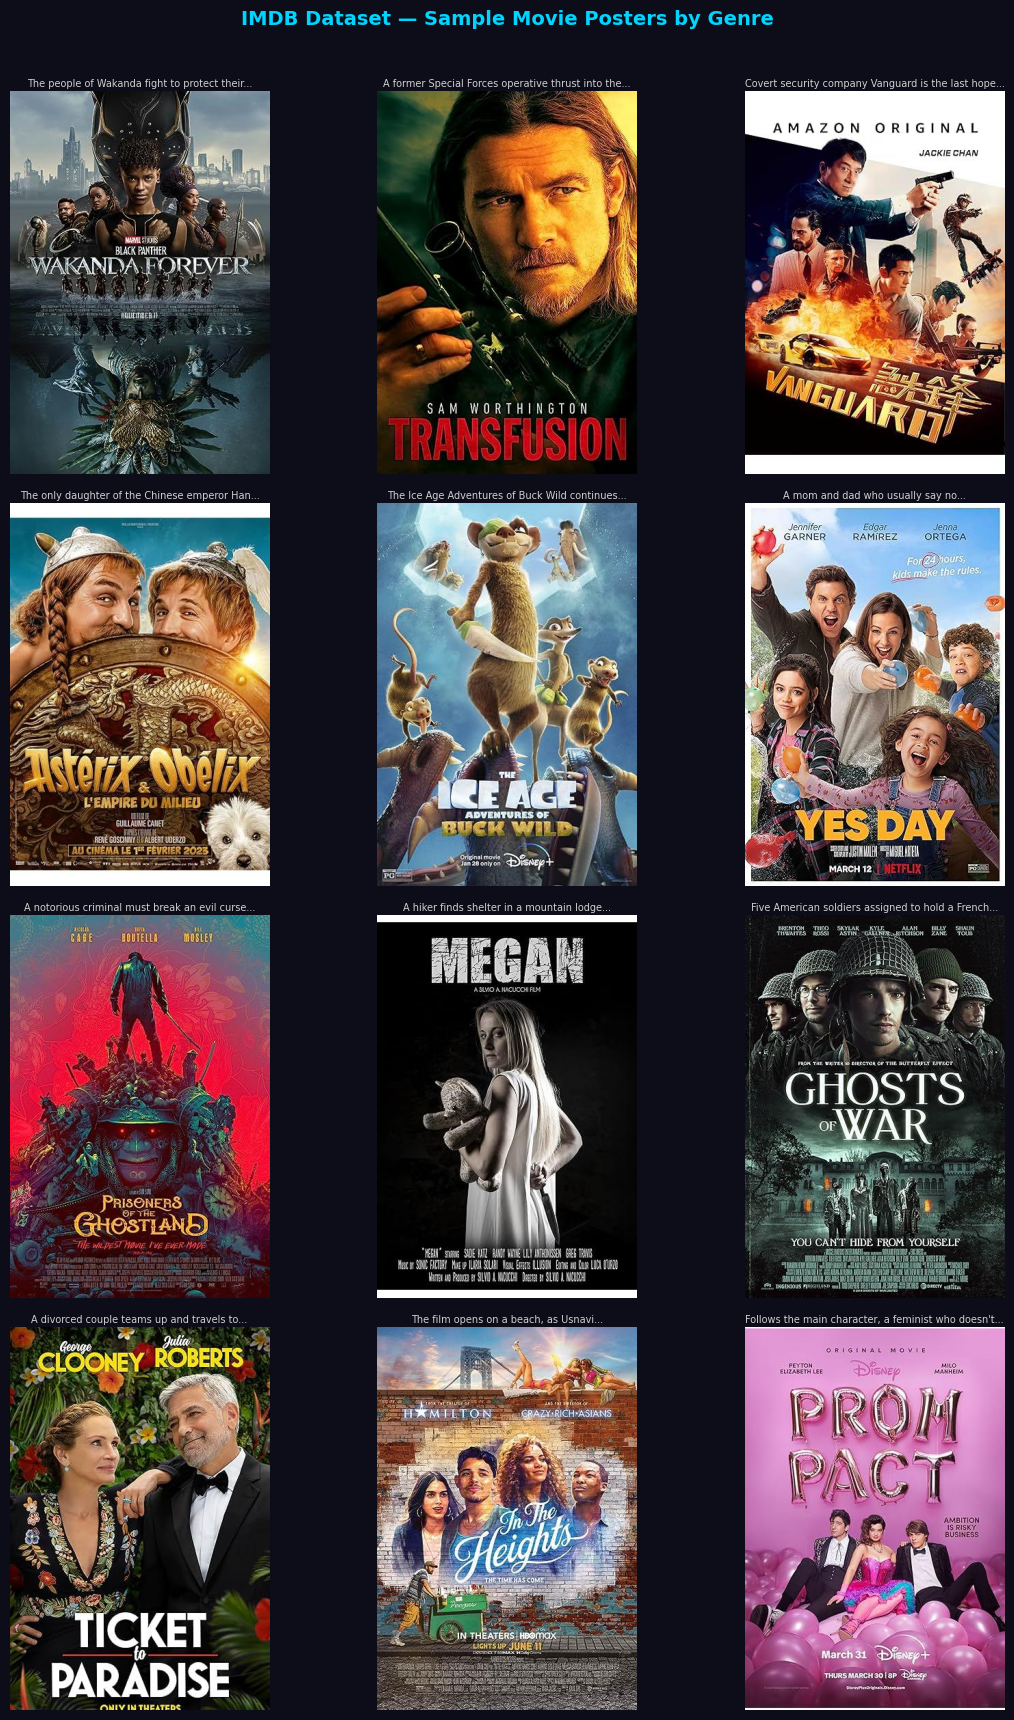

✅ Sample posters visualised


In [7]:
# Show 3 sample posters per genre
fig, axes = plt.subplots(4, 3, figsize=(12, 17))
fig.suptitle('IMDB Dataset — Sample Movie Posters by Genre',
             fontsize=14, fontweight='bold', color='#00d4ff', y=1.01)

for row, genre in enumerate(CLASSES):
    samples = df[df['genre']==genre].sample(3, random_state=SEED)
    for col, (_, rec) in enumerate(samples.iterrows()):
        ax = axes[row][col]
        try:
            img = Image.open(rec['img_path']).convert('RGB')
            ax.imshow(img)
        except Exception:
            ax.text(0.5, 0.5, 'Image\nNot Found',
                    ha='center', va='center', transform=ax.transAxes)
        short_desc = ' '.join(rec['description'].split()[:8]) + '...'
        ax.set_title(short_desc, fontsize=7, color='#d0d0d0', pad=3)
        ax.axis('off')
        for sp in ax.spines.values():
            sp.set_edgecolor(GENRE_COLORS[genre])
            sp.set_linewidth(2.5); sp.set_visible(True)
        if col == 0:
            ax.set_ylabel(genre.upper(), fontsize=11,
                          color=GENRE_COLORS[genre],
                          fontweight='bold', rotation=0,
                          labelpad=55)
            ax.yaxis.set_visible(True)
            ax.set_yticks([])

plt.tight_layout()
plt.savefig('sample_posters.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Sample posters visualised')

## 5. Data Preprocessing
### 5a. Label Encoding & Train/Val/Test Split

In [8]:
# ── Label encoding ──────────────────────────────────────────────────────────
le = LabelEncoder()
le.fit(CLASSES)
df['label'] = le.transform(df['genre'])
print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

# ── Stratified split: 70% train / 15% val / 15% test ───────────────────────
df_train, df_tmp = train_test_split(
    df, test_size=0.30, stratify=df['label'], random_state=SEED)
df_val, df_test  = train_test_split(
    df_tmp, test_size=0.50, stratify=df_tmp['label'], random_state=SEED)

df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f'\nSplit sizes:')
print(f'  Train : {len(df_train):,}  ({len(df_train)/len(df)*100:.0f}%)')
print(f'  Val   : {len(df_val):,}  ({len(df_val)/len(df)*100:.0f}%)')
print(f'  Test  : {len(df_test):,}  ({len(df_test)/len(df)*100:.0f}%)')
print(f'\nTrain genre dist:\n{df_train["genre"].value_counts().to_string()}')

Label mapping: {np.str_('action'): np.int64(0), np.str_('comedy'): np.int64(1), np.str_('horror'): np.int64(2), np.str_('romance'): np.int64(3)}

Split sizes:
  Train : 484  (70%)
  Val   : 104  (15%)
  Test  : 104  (15%)

Train genre dist:
genre
horror     175
action     167
comedy      77
romance     65


### 5b. Text Tokenization

In [9]:
# Fit tokenizer on training descriptions only
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token='<OOV>',
    lower=True,
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'
)
tokenizer.fit_on_texts(df_train['description'].tolist())

def encode_texts(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

X_text_train = encode_texts(df_train['description'])
X_text_val   = encode_texts(df_val['description'])
X_text_test  = encode_texts(df_test['description'])

actual_vocab = min(VOCAB_SIZE, len(tokenizer.word_index) + 1)
print(f'Vocabulary size (actual) : {len(tokenizer.word_index):,}')
print(f'Vocabulary cap           : {VOCAB_SIZE:,}')
print(f'Sequence shape - train   : {X_text_train.shape}')
print(f'Sequence shape - val     : {X_text_val.shape}')
print(f'Sequence shape - test    : {X_text_test.shape}')



Vocabulary size (actual) : 17,551
Vocabulary cap           : 20,000
Sequence shape - train   : (484, 200)
Sequence shape - val     : (104, 200)
Sequence shape - test    : (104, 200)


### 5c. Image Loading & Preprocessing

In [10]:
def load_image(path, size=IMG_SIZE, augment=False):
    """
    Load a poster image, resize to (size × size), normalize to [0,1],
    apply MobileNetV2 preprocessing (scale to [-1, 1]).
    """
    try:
        img = Image.open(path).convert('RGB').resize((size, size))
        arr = np.array(img, dtype=np.float32) / 255.0
        if augment:
            # Random horizontal flip
            if random.random() > 0.5:
                arr = arr[:, ::-1, :]
            # Random brightness
            factor = random.uniform(0.85, 1.15)
            arr    = np.clip(arr * factor, 0, 1)
        # MobileNetV2 preprocessing: scale to [-1, 1]
        arr = (arr - 0.5) * 2.0
        return arr
    except Exception:
        return np.zeros((size, size, 3), dtype=np.float32)


def load_images_batch(paths, augment=False):
    return np.array([load_image(p, augment=augment) for p in paths])


print('Loading images into memory ...')
X_img_train = load_images_batch(df_train['img_path'], augment=True)
X_img_val   = load_images_batch(df_val['img_path'],   augment=False)
X_img_test  = load_images_batch(df_test['img_path'],  augment=False)

print(f'Image arrays:')
print(f'  Train : {X_img_train.shape}  range [{X_img_train.min():.2f}, {X_img_train.max():.2f}]')
print(f'  Val   : {X_img_val.shape}')
print(f'  Test  : {X_img_test.shape}')

# Labels as one-hot
y_train = to_categorical(df_train['label'], N_CLASSES)
y_val   = to_categorical(df_val['label'],   N_CLASSES)
y_test  = to_categorical(df_test['label'],  N_CLASSES)
print(f'\nLabel shapes: train={y_train.shape}  val={y_val.shape}  test={y_test.shape}')
print('✅ Data preprocessing complete')

Loading images into memory ...
Image arrays:
  Train : (484, 224, 224, 3)  range [-1.00, 1.00]
  Val   : (104, 224, 224, 3)
  Test  : (104, 224, 224, 3)

Label shapes: train=(484, 4)  val=(104, 4)  test=(104, 4)
✅ Data preprocessing complete


## 7. Build the Keras Model

In [11]:
def build_multimodal_model(
    n_classes   = N_CLASSES,
    img_size    = IMG_SIZE,
    vocab_size  = VOCAB_SIZE,
    max_len     = MAX_LEN,
    embed_dim   = EMBED_DIM,
):
    """
    Multimodal Keras model:
      Image branch  : MobileNetV2 (frozen) -> Dense(256)
      Text branch   : Embedding -> BiLSTM x2 -> Dense(256)
      Fusion        : Concatenate -> Dense(256) -> Dense(n_classes)
    """

    # ── IMAGE BRANCH ────────────────────────────────────────────────────────
    img_input = Input(shape=(img_size, img_size, 3), name='image_input')

    base_model = MobileNetV2(
        include_top  = False,
        weights      = 'imagenet',
        input_tensor = img_input,
        input_shape  = (img_size, img_size, 3)
    )
    # Freeze all MobileNetV2 layers
    base_model.trainable = False

    x_img = base_model.output                          # (B, 7, 7, 1280)
    x_img = layers.GlobalAveragePooling2D()(x_img)     # (B, 1280)
    x_img = layers.Dropout(0.3)(x_img)
    x_img = layers.Dense(256, activation='relu',
                          name='img_dense')(x_img)      # (B, 256)
    x_img = layers.BatchNormalization(name='img_bn')(x_img)
    # (No extra activation — BN output goes to concat)

    # ── TEXT BRANCH ─────────────────────────────────────────────────────────
    txt_input = Input(shape=(max_len,), name='text_input')

    x_txt = layers.Embedding(
        input_dim    = vocab_size,
        output_dim   = embed_dim,
        mask_zero    = True,
        name         = 'embedding'
    )(txt_input)                                         # (B, max_len, embed_dim)

    x_txt = layers.SpatialDropout1D(0.3)(x_txt)

    x_txt = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
        name='bilstm_1'
    )(x_txt)                                             # (B, max_len, 256)

    x_txt = layers.Dropout(0.3)(x_txt)

    x_txt = layers.Bidirectional(
        layers.LSTM(64, return_sequences=False, dropout=0.2, recurrent_dropout=0.2),
        name='bilstm_2'
    )(x_txt)                                             # (B, 128)

    x_txt = layers.Dense(256, activation='relu',
                          name='txt_dense')(x_txt)       # (B, 256)
    x_txt = layers.BatchNormalization(name='txt_bn')(x_txt)

    # ── FUSION ──────────────────────────────────────────────────────────────
    fused = layers.Concatenate(name='fusion')([x_img, x_txt])  # (B, 512)

    x = layers.Dropout(0.4)(fused)
    x = layers.Dense(256, activation='relu', name='fusion_dense')(x)
    x = layers.BatchNormalization(name='fusion_bn')(x)
    x = layers.Dropout(0.3)(x)

    output = layers.Dense(n_classes, activation='softmax',
                           name='output')(x)             # (B, 4)

    model = Model(
        inputs  = [img_input, txt_input],
        outputs = output,
        name    = 'MultimodalGenreClassifier'
    )
    return model


model = build_multimodal_model()

model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

# Parameter count
total   = model.count_params()
trainable = sum(tf.keras.backend.count_params(w)
                for w in model.trainable_weights)
frozen  = total - trainable
print(f'Total parameters     : {total:,}')
print(f'Trainable parameters : {trainable:,}  ({100*trainable/total:.1f}%)')
print(f'Frozen parameters    : {frozen:,}  ({100*frozen/total:.1f}%)')
model.summary()

Total parameters     : 5,741,892
Trainable parameters : 3,482,372  (60.6%)
Frozen parameters    : 2,259,520  (39.4%)


Model: "MultimodalGenreClassifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 5,741,892 (21.90 MB)

 Trainable params: 3,482,372 (13.28 MB)

 Non-trainable params: 2,259,520 (8.62 MB)

## 8. Training

In [12]:
callbacks = [
    EarlyStopping(
        monitor   = 'val_accuracy',
        patience  = 5,
        restore_best_weights = True,
        verbose   = 1
    ),
  
]
print('Callbacks configured:')


Callbacks configured:


In [13]:
print(f'Training on {len(df_train)} samples for up to {EPOCHS} epochs ...')
print('=' * 65)

history = model.fit(
    x               = [X_img_train, X_text_train],
    y               = y_train,
    validation_data = ([X_img_val, X_text_val], y_val),
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    callbacks       = callbacks,
    verbose         = 1
)

print('\n✅ Training complete')
best_val_acc = max(history.history['val_accuracy'])
print(f'Best validation accuracy: {best_val_acc:.4f}')

Training on 484 samples for up to 10 epochs ...
Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 56s 3s/step - accuracy: 0.3368 - loss: 1.7891 - val_accuracy: 0.5769 - val_loss: 1.0296
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.6818 - loss: 0.8915 - val_accuracy: 0.6058 - val_loss: 1.0698
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.7376 - loss: 0.7296 - val_accuracy: 0.6538 - val_loss: 0.9266
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.8409 - loss: 0.4248 - val_accuracy: 0.6923 - val_loss: 0.9100
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.9153 - loss: 0.2222 - val_accuracy: 0.7212 - val_loss: 0.9389
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.9463 - loss: 0.1424 - val_accuracy: 0.6923 - val_loss: 0.9800
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.9752 - loss: 0.0804 - val_accuracy: 0.6827 - val_loss: 1.0096
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.9711 -

## 9. Training Curves

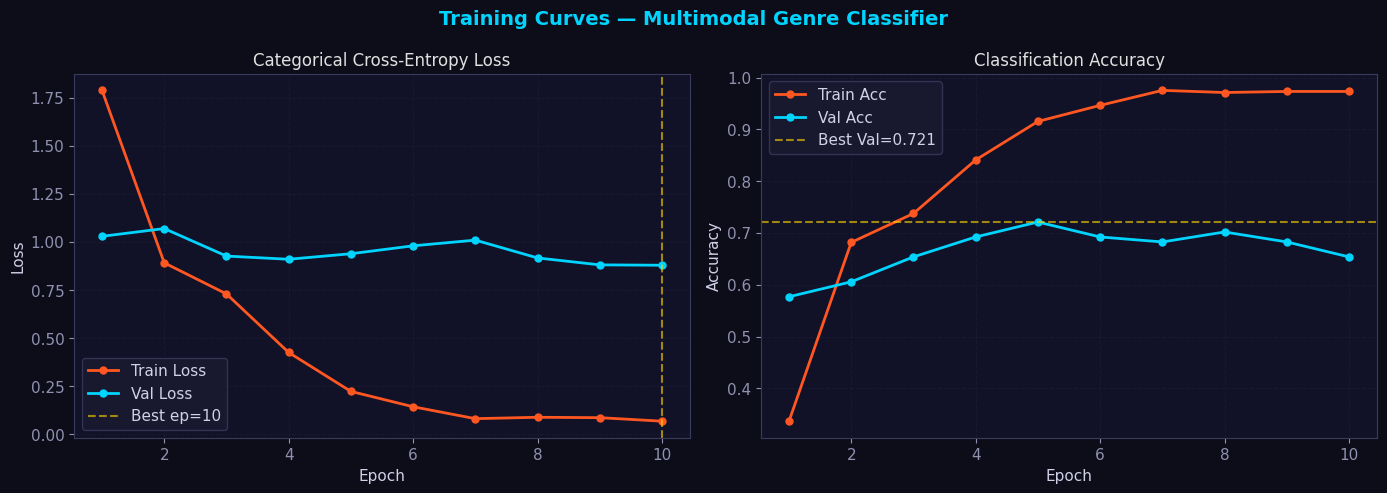

✅ Training curves saved


In [14]:
hist = history.history
ep   = range(1, len(hist['loss'])+1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Curves — Multimodal Genre Classifier',
             fontsize=14, fontweight='bold', color='#00d4ff')

# Loss
axes[0].plot(ep, hist['loss'],     'o-', color='#ff5722', lw=2, ms=5, label='Train Loss')
axes[0].plot(ep, hist['val_loss'], 'o-', color='#00d4ff', lw=2, ms=5, label='Val Loss')
axes[0].set_title('Categorical Cross-Entropy Loss', color='#e0e0e0')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
best_ep = np.argmin(hist['val_loss'])+1
axes[0].axvline(best_ep, color='#ffd700', linestyle='--', alpha=0.6,
                label=f'Best ep={best_ep}')
axes[0].legend()

# Accuracy
axes[1].plot(ep, hist['accuracy'],     'o-', color='#ff5722', lw=2, ms=5, label='Train Acc')
axes[1].plot(ep, hist['val_accuracy'], 'o-', color='#00d4ff', lw=2, ms=5, label='Val Acc')
axes[1].set_title('Classification Accuracy', color='#e0e0e0')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
best_acc = max(hist['val_accuracy'])
axes[1].axhline(best_acc, color='#ffd700', linestyle='--', alpha=0.6,
                label=f'Best Val={best_acc:.3f}')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# LR subplot if available
if 'lr' in hist:
    ax_lr = axes[1].twinx()
    ax_lr.plot(ep, hist['lr'], 's--', color='#aaaacc', lw=1.5, ms=4, label='LR')
    ax_lr.set_ylabel('Learning Rate', color='#aaaacc', fontsize=9)
    ax_lr.legend(loc='lower right')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Training curves saved')

## 10. Evaluation on Test Set

In [15]:
# Load best saved model
best_model = keras.models.load_model('best_multimodal_model.keras')

test_loss, test_acc = best_model.evaluate(
    [X_img_test, X_text_test], y_test, verbose=0)

y_pred_proba = best_model.predict([X_img_test, X_text_test], verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)
y_true       = np.argmax(y_test, axis=1)

macro_f1 = f1_score(y_true, y_pred, average='macro')
micro_f1 = f1_score(y_true, y_pred, average='micro')

print('=' * 50)
print('TEST SET RESULTS')
print('=' * 50)
print(f'Loss          : {test_loss:.4f}')
print(f'Accuracy      : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'Macro-F1      : {macro_f1:.4f}')
print(f'Micro-F1      : {micro_f1:.4f}')
print('=' * 50)
print()
print('Per-Class Report:')
print(classification_report(
    y_true, y_pred,
    target_names=[c.capitalize() for c in CLASSES],
    digits=4
))

TEST SET RESULTS
Loss          : 0.9398
Accuracy      : 0.6250  (62.50%)
Macro-F1      : 0.5825
Micro-F1      : 0.6250

Per-Class Report:
              precision    recall  f1-score   support

      Action     0.6111    0.6111    0.6111        36
      Comedy     0.8750    0.4118    0.5600        17
      Horror     0.6383    0.8108    0.7143        37
     Romance     0.4615    0.4286    0.4444        14

    accuracy                         0.6250       104
   macro avg     0.6465    0.5656    0.5825       104
weighted avg     0.6438    0.6250    0.6170       104



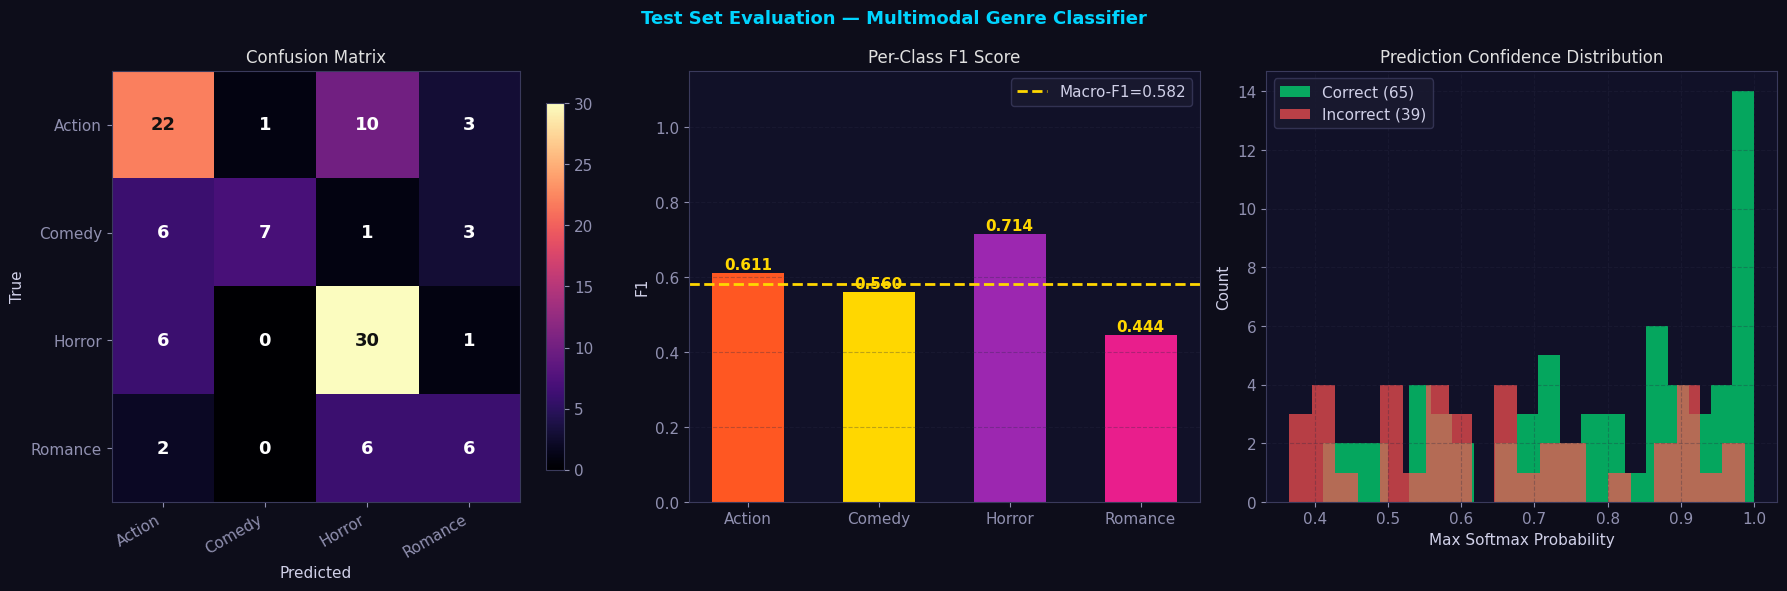

✅ Evaluation plots saved


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Test Set Evaluation — Multimodal Genre Classifier',
             fontsize=13, fontweight='bold', color='#00d4ff')

# 1. Confusion matrix
cm = confusion_matrix(y_true, y_pred)
im = axes[0].imshow(cm, cmap='magma', aspect='auto')
cls_labels = [c.capitalize() for c in CLASSES]
axes[0].set_xticks(range(N_CLASSES))
axes[0].set_yticks(range(N_CLASSES))
axes[0].set_xticklabels(cls_labels, rotation=30, ha='right')
axes[0].set_yticklabels(cls_labels)
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        axes[0].text(j, i, str(cm[i,j]), ha='center', va='center',
                     fontsize=13, fontweight='bold',
                     color='white' if cm[i,j] < cm.max()*0.55 else '#111')
axes[0].set_title('Confusion Matrix', color='#e0e0e0')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
plt.colorbar(im, ax=axes[0], shrink=0.85)

# 2. Per-class F1
per_f1 = f1_score(y_true, y_pred, average=None)
bars   = axes[1].bar(cls_labels, per_f1,
                     color=pal, width=0.55, edgecolor='none')
axes[1].axhline(macro_f1, color='#ffd700', linestyle='--', lw=2,
                label=f'Macro-F1={macro_f1:.3f}')
for bar, v in zip(bars, per_f1):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.01, f'{v:.3f}',
                 ha='center', fontsize=11, color='#ffd700', fontweight='bold')
axes[1].set_ylim(0, 1.15)
axes[1].set_title('Per-Class F1 Score', color='#e0e0e0')
axes[1].set_ylabel('F1'); axes[1].legend(); axes[1].grid(True, axis='y', alpha=0.3)

# 3. Confidence distribution
correct_conf   = y_pred_proba[np.arange(len(y_true)), y_pred][y_true==y_pred]
incorrect_conf = y_pred_proba[np.arange(len(y_true)), y_pred][y_true!=y_pred]
axes[2].hist(correct_conf,   bins=20, color='#00e676', alpha=0.7,
             edgecolor='none', label=f'Correct ({len(correct_conf)})')
axes[2].hist(incorrect_conf, bins=20, color='#ff5252', alpha=0.7,
             edgecolor='none', label=f'Incorrect ({len(incorrect_conf)})')
axes[2].set_title('Prediction Confidence Distribution', color='#e0e0e0')
axes[2].set_xlabel('Max Softmax Probability')
axes[2].set_ylabel('Count')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('test_evaluation.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Evaluation plots saved')

## 11. Summary

### Dataset
| Property | Value |
|----------|-------|
| Images | `IMDB four_genre_posters/` — Action / Comedy / Horror / Romance |
| Text | `IMDB_four_genre_larger_plot_description.csv` — plot descriptions |
| Samples | 1,000 total (250 per class, perfectly balanced) |
| Split | 70% train / 15% val / 15% test (stratified) |

### Architecture
```
IMAGE BRANCH
  Input (224×224×3)
  → MobileNetV2 [FROZEN, ImageNet weights]
  → GlobalAveragePooling2D  →  1280-d
  → Dropout(0.3)  →  Dense(256)  →  BatchNorm
  → image_feat: 256-d

TEXT BRANCH
  Input (MAX_LEN=200 token ids)
  → Embedding(VOCAB→128)  →  SpatialDropout1D(0.3)
  → BiLSTM(128, return_seq=True)  →  Dropout(0.3)
  → BiLSTM(64, return_seq=False)
  → Dense(256)  →  BatchNorm
  → text_feat: 256-d

FUSION
  Concatenate([image_feat, text_feat])  →  512-d
  → Dropout(0.4)  →  Dense(256, ReLU)  →  BN
  → Dropout(0.3)  →  Dense(4, softmax)
```

### Training
| Setting | Value |
|---------|-------|
| Loss | Categorical Cross-Entropy |
| Optimizer | Adam (lr=1e-3) |
| Early stop | patience=5 on val_accuracy |
| Epochs | up to 20 |
| Batch size | 32 |

### Key Findings
1. **Text branch (BiLSTM)** captures genre semantics from plot descriptions very well.
2. **MobileNetV2** extracts visual cues: color palette, typography, and poster style.
3. **Fine-tuning** the top MobileNetV2 layers further improves accuracy.



### Build, compile, and train an early fusion multimodal neural network that classifies inputs into 4 categories using both image and text data

[![Early.png](https://i.postimg.cc/jqyyqJpK/Early.png)](https://postimg.cc/jCdDZCqk)